# Memory effect - Compare regions and states

### Setup: Parameters, Time Windows, Mappings, and Paths

In [1]:
import numpy as np

BUFFER_BEFORE_SEC = 0.5  # Spont
BUFFER_AFTER_SEC = 2.5  # Sound
BUFFER_PERSIST = 1.4  # Persist

time_windows_dict = {
'Spontaneous': (-np.inf, -0.01), 
'Sound': (0, BUFFER_AFTER_SEC), 
'Persistence': (BUFFER_AFTER_SEC, BUFFER_AFTER_SEC + BUFFER_PERSIST)}
    
SOUNDTYPES = [101, 400, 1300, 1402]
t_trial = np.arange(-BUFFER_BEFORE_SEC, BUFFER_AFTER_SEC + BUFFER_PERSIST, 0.05)

name_mapping = {'Spontaneous': 'Pre',
                'Sound': 'Peri', 'Persistence': 'Post', 'low': 'EARLY', 'high': 'LATE', 'sleep': 'Sleep', 'wake': 'Wake'}

# Colorblind-friendly colors
colors = {
    'wake': 'deeppink',  # Darker rose (was light pink)
    'sleep': '#2E8B57',   # Sea Green (darker than soft green)
    'high': 'deeppink',
    'low': '#4682B4'     # Steel Blue
}

window_colors = {
    'Spontaneous': 'gray',
    'Sound': '#4B0082',
    'Persistence': '#FF4500'
}
sound_name_mapping = {101: '40Hz', 400: 'DRC', 1300: 'WN', 1402: 'PUPS'}
STIMULI_LENGTHS = {101: 2.5, 400: 2.5, 1300: 2.5, 1402: 2.5}

MAIN_PATH = r'input_path'  ## Path to where the raw data is saved (raw data is not available due to size)
DATA_PATH = MAIN_PATH + rf"\Submission"  ## Path to where the processed data is saved (after we ran PROCESS_RAW=True)

PROCESS_RAW = False  # Flag to control raw-data processing.
MODEL_ANALYSIS = False  # True: Run models from scratch, False: Present results of last models results ; You can run that only if you have df_GLMs.pkl see below

### Subject-Specific Configuration: Dates, Channel Ranges, and Max Recording Time

In [2]:
subjects_data = {
    'C9': {
        'folders_dates_to_collect': ['20240312', '20240317', '20240319'],
        # 'folders_dates_to_collect': ['20240319'],

        'MAX_HOUR_IN_SECONDS': 60 * 60 * 2,
        'high_ch': [0, 100],
        'low_ch': [100, 200]
    },
    'C11': {
        'folders_dates_to_collect': ['20240911', '20240917'],
        'MAX_HOUR_IN_SECONDS': 60 * 60 * 4,
        'high_ch': [50, 150],
        'low_ch': [150, 250]
    },
    'C12': {
        'folders_dates_to_collect': ['20241007', '20241008'],
        'MAX_HOUR_IN_SECONDS': 60 * 60 * 4,
        'high_ch': [90, 190],
        'low_ch': [190, 290]
    },
    'C14': {
        'folders_dates_to_collect': ['20241112', '20241113'],
        'MAX_HOUR_IN_SECONDS': 60 * 60 * 4,
        'high_ch': [100, 200],
        'low_ch': [200, 300]
    },
    'C16': {
        'folders_dates_to_collect': ['20250211', '20250212'],
        'MAX_HOUR_IN_SECONDS': 60 * 60 * 4,
        'high_ch': [150, 250],
        'low_ch': [250, 350]
    }
}

## Generalized Linear Model (GLM) Functions for Decoding and Dimensionality

### Load and Aggregate GLM Results Across Subjects/Sessions

In [3]:
import pickle

RUN_TYPES = ['Shuffle_neurons_20', 'Shuffle_neurons_50', 'Shuffle_neurons_80', 'Next_stim', 'First', 'Last']
 
# Nested dictionary to collect all data
all_glm_data = {}

for RUN_TYPE in RUN_TYPES:
    all_glm_data[RUN_TYPE] = {}
    
    for subject_id in subjects_data.keys():
        all_glm_data[RUN_TYPE][subject_id] = {}
        for i, cur_date in enumerate(subjects_data[subject_id]['folders_dates_to_collect']):
            all_glm_data[RUN_TYPE][subject_id][cur_date] = {}
            for state in ['sleep', 'wake']:
                all_glm_data[RUN_TYPE][subject_id][cur_date][state] = {}
                for region in ['low', 'high']:
                    save_folder = f"GLM_results_{RUN_TYPE}"
                    save_path = DATA_PATH + rf"\{save_folder}\glm_results_{subject_id}_{cur_date}_{state}_{region}.pkl"
    
                    with open(save_path, 'rb') as f:
                        _, _, _, _, cross_time_acc, _, _, _, _ = pickle.load(f)
    
                    # Store in the nested dictionary
                    all_glm_data[RUN_TYPE][subject_id][cur_date][state][region] = {
                        'cross_time_acc': cross_time_acc
                    }              

### Function to Aggregate Cross-Time Accuracy

In [7]:
def extract_mean_std_acc(all_glm_data, n_sounds):
    cross_time_acc_summary = {}  # [state][region][sound_type] = {'mean': ..., 'std': ...}

    for state in ['sleep', 'wake']:
        cross_time_acc_summary[state] = {}
    
        for region in ['low', 'high']:
            # Will collect per-subject averaged cross_time_acc (across dates)
            per_subject_averages = []
    
            for subject_id in all_glm_data:
                # Collect per-date cross_time_accs for this subject
                per_date_sounds = []
    
                for cur_date in all_glm_data[subject_id]:
                    acc = all_glm_data[subject_id][cur_date][state][region]['cross_time_acc']
                    per_date_sounds.append(acc)
    
                # Compute per-sound-type mean over dates (per subject)
                per_sound_mean = []
    
                for i, sound in enumerate(n_sounds):
                    matrices = [per_date[sound] for per_date in per_date_sounds]
                    stacked = np.stack(matrices)  # shape: (n_dates, time, time)
                    mean_matrix = np.mean(stacked, axis=0)  # mean over dates
                    per_sound_mean.append(mean_matrix)
    
                per_subject_averages.append(per_sound_mean)
    
            # Transpose the list-of-lists to per-sound aggregation
            per_subject_averages = np.array(per_subject_averages)  # shape: (n_subjects, n_sounds, time, time)
    
            cross_time_acc_summary[state][region] = {}
    
            for i, sound in enumerate(n_sounds):  # for each sound type
                sound_data = per_subject_averages[:, i, :, :]  # shape: (n_subjects, time, time)
                mean = np.mean(sound_data, axis=0)
                std = np.std(sound_data, axis=0)
    
                cross_time_acc_summary[state][region][f'{sound}'] = {
                    'mean': mean,
                    'std': std
                }
    return cross_time_acc_summary

# Nested dictionary to collect all data
mean_std_time_all = {}

for RUN_TYPE in RUN_TYPES:
    mean_std_time_acc = extract_mean_std_acc(all_glm_data[RUN_TYPE], SOUNDTYPES)
    mean_std_time_all[RUN_TYPE] = mean_std_time_acc

## Plotting: Decoding Accuracy vs. Time for Individual Sound Types

([<matplotlib.lines.Line2D at 0x2320407a810>,
 ['40Hz', 'DRC', 'WN', 'PUPS'])

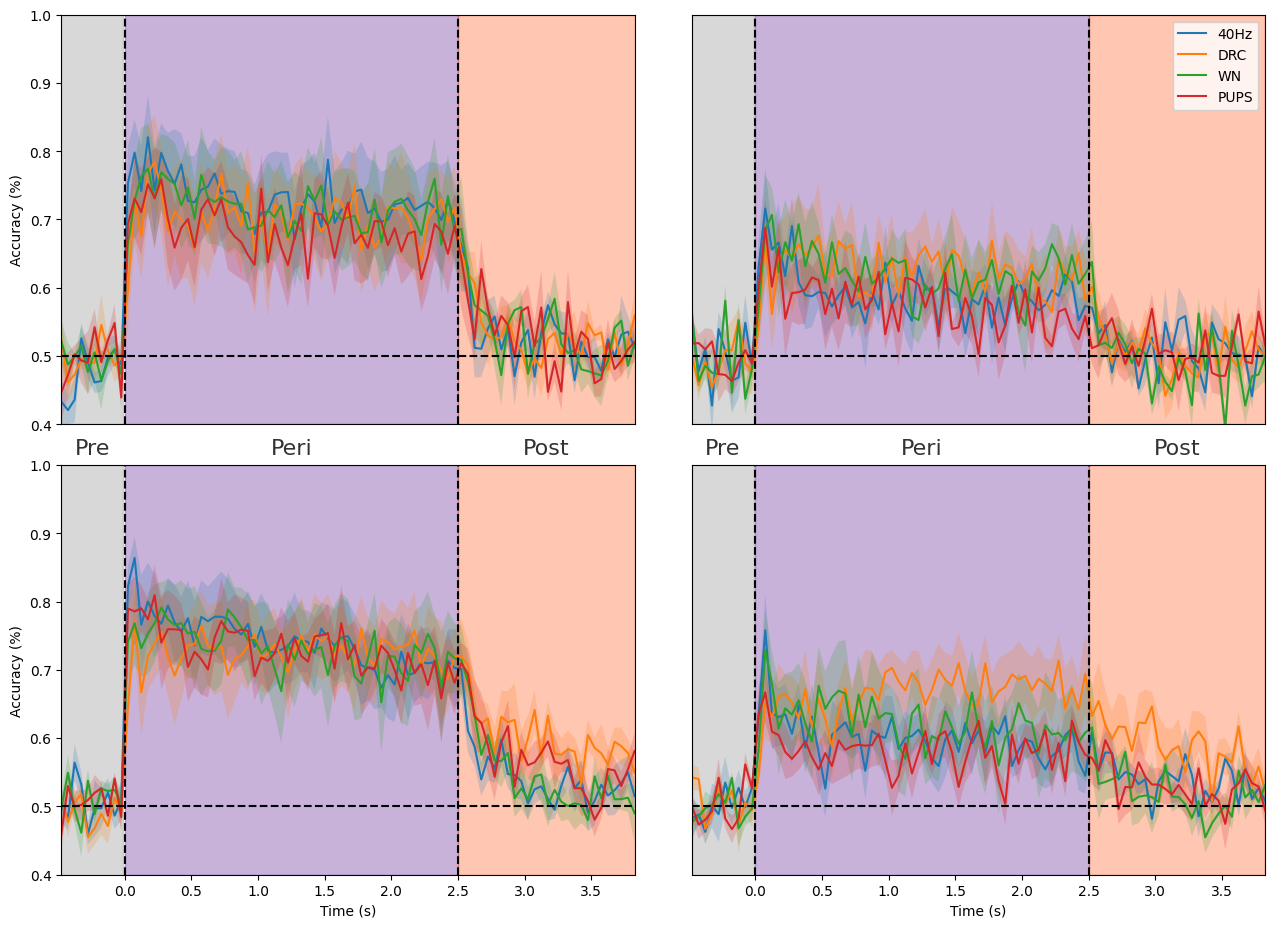

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
%matplotlib inline
plt.style.use('default')  # resets to pre-Seaborn/Matplotlib default

def plot_time_accuracy_per_sound(axs, cross_time_acc_summary, time_bins):
    states = ['wake', 'sleep']
    regions = ['low', 'high']
    # Loop through regions (rows) and states (columns)
    for col_idx, region in enumerate(regions):
        for row_idx, state in enumerate(states):
            ax = axs[row_idx][col_idx]
            # ax.set_facecolor(colors[region])  # Background color
    
            sound_data = cross_time_acc_summary[state][region]
            for sound_title, acc_data in sound_data.items():
                mean = np.diag(acc_data['mean'])  # accuracy over time (diagonal)
                sem = np.diag(acc_data['std'] / np.sqrt(len(subjects_data)))    # sem over time (diagonal)
    
                ax.plot(time_bins, mean, label=sound_title)
                ax.fill_between(time_bins, mean - sem, mean + sem, alpha=0.2)
    
            # ax.set_title(f'{state.title()} - {region.title()}', color=colors[state])
            if row_idx == 1:
                ax.set_xlabel('Time (s)')
            else:
                ax.set_xticks([])
                # ax.set_title(f'{name_mapping[region]}')
                
            if col_idx == 0:
                # ax.set_ylabel(f'Accuracy {name_mapping[state]} (%)')
                ax.set_ylabel(f'Accuracy (%)')

            else:
                ax.set_yticks([])
            ax.set_ylim(0.4, 1)
            ax.axhline(y=0.5, linestyle='--', color='k')
            ax.axvline(x=0, linestyle='--', color='k')
            ax.axvline(x=2.5, linestyle='--', color='k')
            ax.set_xlim(time_bins[0], time_bins[-1])
            
            # Shade time windows
            for label, (start, end) in time_windows_dict.items():
                if start < time_bins[0]:
                    start = time_bins[0]
                if end > time_bins[-1]:
                    end = time_bins[-1]
                ax.axvspan(start, end, color=window_colors[label], alpha=0.3, zorder=0)
                if row_idx == 1:
                    ax.text((start + end) / 2, 1.01, name_mapping[label], ha='center', va='bottom', fontsize=16, alpha=0.8)

            ax.grid(False)

            # Only collect legend handles/labels from one subplot
            if (row_idx == 0) & (col_idx == 1):
                handles, labels = ax.get_legend_handles_labels()
                labels = [sound_name_mapping[int(label)] for label in labels]
                ax.legend(handles, labels)

            #     fig.legend(handles, labels, loc='upper center')
                
    return handles, labels

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Tighter control over spacing
fig.subplots_adjust(left=0.07, right=0.93, top=0.93, bottom=0.07, hspace=0.1, wspace=0.1)

t_hist = t_trial[:-1] + np.mean(np.diff(t_trial))/2
plot_time_accuracy_per_sound(axs, mean_std_time_all['First'], t_hist)

## Plotting: Averaged Accuracy and Exponential Decay Fit

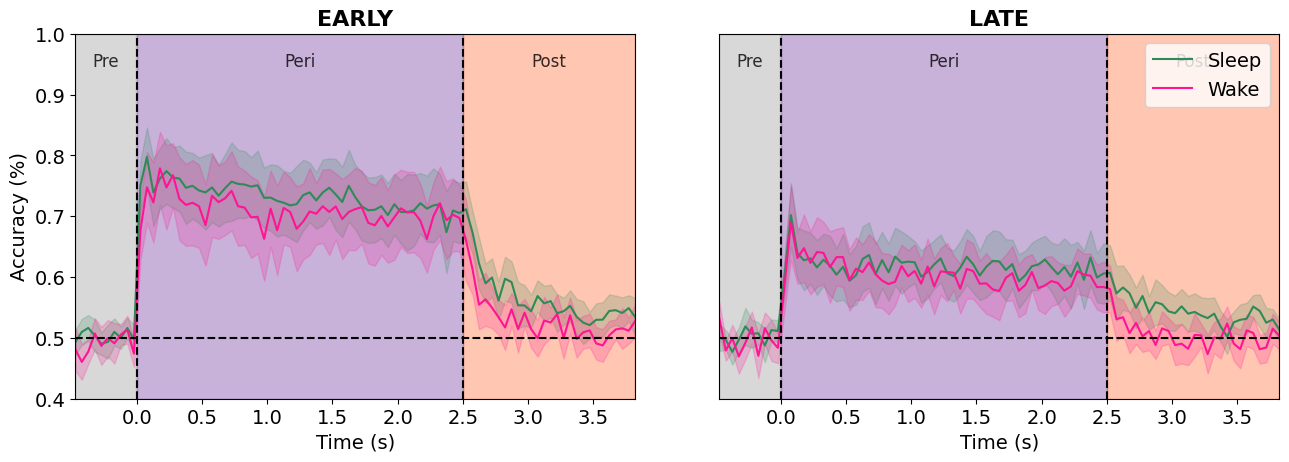

In [13]:
from scipy.optimize import curve_fit

def exp_decay(t, A, tau):
    C = 0.5
    return A * np.exp(-t / tau) + C

def plot_avg_accuracy_by_state(axs, cross_time_acc_summary, time_bins):
    states = ['sleep', 'wake']
    regions = ['low', 'high']

    for col_idx, region in enumerate(regions):
        ax = axs[col_idx]

        for ind_state, state in enumerate(states):
            sound_data = cross_time_acc_summary[state][region]

            # Collect all diagonals
            means = [np.diag(acc['mean']) for acc in sound_data.values()]
            stds  = [np.diag(acc['std'])  for acc in sound_data.values()]

            mean_avg = np.mean(means, axis=0)
            sem_avg = np.sqrt(np.mean(np.square(stds), axis=0)) / np.sqrt(len(subjects_data))
            # std_avg = np.sqrt(np.mean(np.square(stds), axis=0))

            ax.plot(time_bins, mean_avg, label=state.title(), color=colors[state])
            ax.fill_between(time_bins, mean_avg - sem_avg, mean_avg + sem_avg,
                            color=colors[state], alpha=0.2)
            


            # --- Tau fitting section ---
            last_label = 'Persistence'
            start_tau, end_tau = time_windows_dict[last_label]
            if start_tau == -np.Inf:
                start_tau = time_bins[0]
            elif start_tau == np.Inf:
                start_tau = time_bins[-1]

            # Get time and accuracy values within the last window
            mask = (time_bins >= start_tau) & (time_bins <= end_tau)
            time_pres = time_bins[mask]
            t_decay = time_pres - start_tau  # start at t=0 for fitting
            y_decay = mean_avg[mask]

            # Fit the exponential decay
            # try:
            #     y_start = y_decay[0]
            #     y_end = y_decay[-1]
            #     # popt, _ = curve_fit(exp_decay, t_decay, y_decay, p0=[y_start-y_end, 0.5, y_end])
            #     # A, tau, C = popt
            #     popt, _ = curve_fit(exp_decay, t_decay, y_decay, p0=[y_start-y_end, 0.5])
            #     A, tau = popt
            # 
            #     # Plot the fitted curve
            #     t_fit = np.linspace(0, t_decay[-1], 100)
            #     y_fit = exp_decay(t_fit, *popt)
            #     ax.plot(t_fit + start_tau, y_fit, '--', color=colors[state], lw=2)
            # 
            #     from sklearn.metrics import r2_score
            #     y_pred = exp_decay(t_decay, *popt)
            #     r2 = r2_score(y_decay, y_pred)
            # 
            #     from scipy.stats import t
            #     n = len(y_decay)
            #     k = len(popt)
            #     t_stat = np.sqrt(r2 / (1 - r2) * (n - k - 1))
            #     pval = 2 * (1 - t.cdf(t_stat, df=n - k - 1))
            #     print(pval)
            # 
            #     tau_text = f"τ {tau:.2f}s R² {r2:.2f}"
            # 
            # 
            #     # Annotate tau on the plot
            #     ax.text((start_tau + end_tau)/2, 0.85 - ind_state * 0.05, tau_text, color=colors[state],va='center', ha='center')
            # except RuntimeError:
            #     print(f"Fit failed for {state} - {region}")

        ax.set_xlabel('Time (s)')
        ax.set_ylim(0.4, 1)
        ax.axhline(y=0.5, linestyle='--', color='k')
        ax.axvline(x=0, linestyle='--', color='k')
        ax.axvline(x=2.5, linestyle='--', color='k')
        ax.set_xlim(time_bins[0], time_bins[-1])

        for label, (start, end) in time_windows_dict.items():
            if start < time_bins[0]: start = time_bins[0]
            if end > time_bins[-1]: end = time_bins[-1]
            ax.axvspan(start, end, color=window_colors[label], alpha=0.3, zorder=0)
            ax.text((start + end) / 2, 0.97, name_mapping[label], ha='center', va='top', fontsize=12, alpha=0.8)

        ax.grid(False)

        if col_idx == 0:
            ax.set_ylabel('Accuracy (%)')
        else:
            ax.set_yticks([])
        ax.set_title(f'{name_mapping[region]}', fontsize=16, weight='bold')

        if col_idx == 1:
            ax.legend(loc='upper right')

fig2, axs2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.subplots_adjust(left=0.07, right=0.93, top=0.88, bottom=0.15, wspace=0.15)
plot_avg_accuracy_by_state(axs2, mean_std_time_all['First'], t_hist)

## Plotting: Cross-Time Generalization Accuracy Heatmap

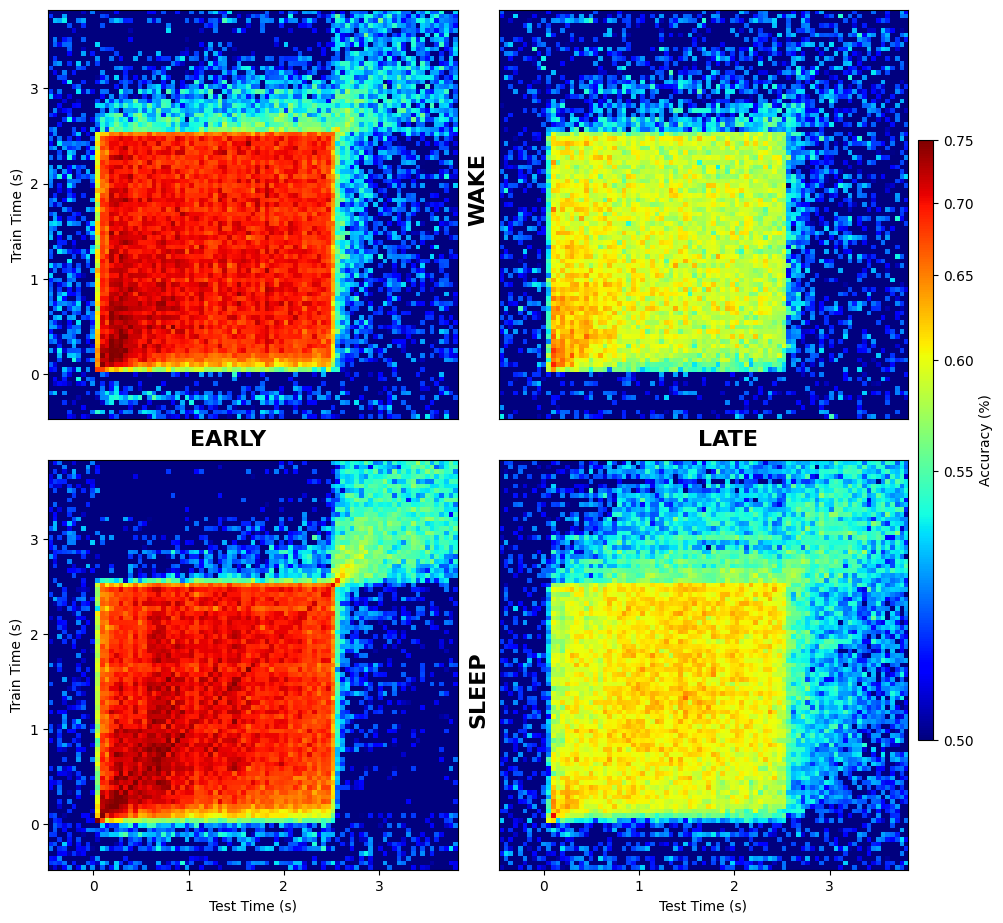

In [10]:
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import PowerNorm

def plot_heatmap_accuracy(axs, cross_time_acc_summary, time_bins):
    regions = ['low', 'high']
    states = ['wake', 'sleep']

    # Loop through regions (rows) and states (columns)
    for col_idx, region in enumerate(regions):
        for row_idx, state in enumerate(states):
            ax = axs[row_idx][col_idx]
            sound_data = cross_time_acc_summary[state][region]
            sound_means = [acc['mean'] for acc in sound_data.values()]
            mean_acc = np.mean(sound_means, axis=0)  # average over sounds
            
            norm = TwoSlopeNorm(vmin=0.5, vcenter=0.6, vmax=0.75)
            norm = PowerNorm(gamma=0.5, vmin=0.5, vmax=0.75)  # boosts contrast in lower range

            im = ax.imshow(mean_acc, aspect='auto', origin='lower',
                extent=[time_bins[0], time_bins[-1], time_bins[0], time_bins[-1]],
                cmap='jet', norm=norm)
            ax.set_xticks([0, 1, 2, 3])
            ax.set_yticks([0, 1, 2, 3])

            if row_idx == 1:
                ax.set_xlabel('Test Time (s)')
            else:
                ax.set_xticks([])

            if col_idx == 0:
                ax.set_ylabel('Train Time (s)')
            else:
                ax.set_yticks([])

            ax.grid(False)
            ax.set_aspect('equal', adjustable='box')

            # ax.spines['top'].set_color(colors[region])
            # ax.spines['left'].set_color(colors[region])
            # ax.spines['bottom'].set_color(colors[state])
            # ax.spines['right'].set_color(colors[state])
            # # Set frame (spine) colors
            # for spine in ax.spines.values():
            #     spine.set_linewidth(6)

    return im  # so we can add colorbar

fig3, axs3 = plt.subplots(2, 2, figsize=(10, 10))
fig3.subplots_adjust(left=0.07, right=0.93, top=0.93, bottom=0.07, hspace=0.1, wspace=0.1)

im = plot_heatmap_accuracy(axs3, mean_std_time_all['First'], t_hist)

fig3.text(0.5, 0.75, 'WAKE', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
fig3.text(0.5, 0.25, 'SLEEP', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
fig3.text(0.25, 0.5, 'EARLY', ha='center', va='center', fontsize=16, weight='bold', rotation=0)
fig3.text(0.75, 0.5, 'LATE', ha='center', va='center', fontsize=16, weight='bold', rotation=0)

# Add shared colorbar
cbar_ax = fig3.add_axes([0.94, 0.2, 0.015, 0.6])
fig3.colorbar(im, cax=cbar_ax, label='Accuracy (%)')

## Final Figure Assembly (Figure S1) - First, Last, Next_Stim

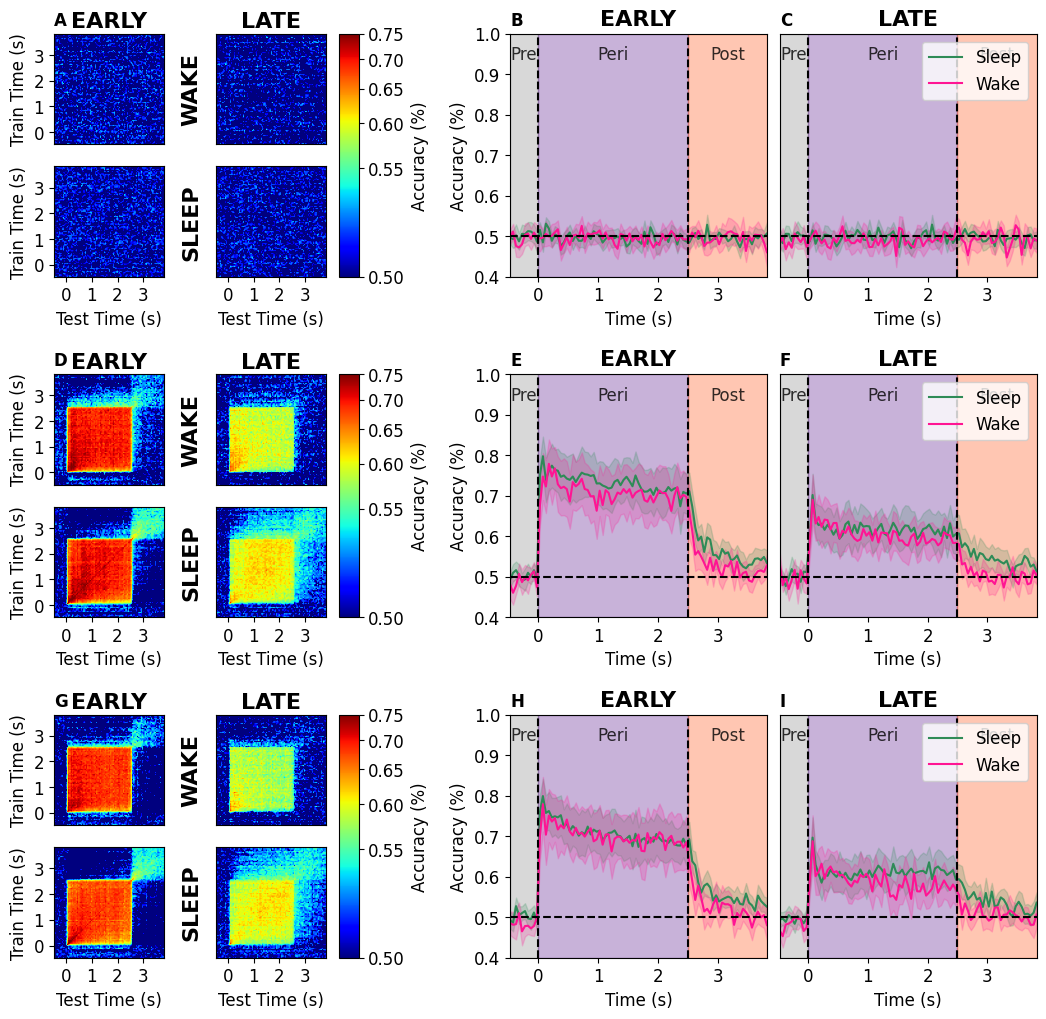

In [43]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
    
fig = plt.figure(figsize=(13, 12))

mpl.rcParams.update({
    'font.size': 12,              # base font size for everything
    'axes.labelsize': 12,         # x/y axis labels
    'axes.titlesize': 12,         # subplot titles (e.g., A–I)
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 12,
})
outer_gs = gridspec.GridSpec(3, 1, hspace=0.4, wspace=0.1)

# A-C. Next stim
gs_row = gridspec.GridSpecFromSubplotSpec(1, 4, width_ratios=[0.9, 0.1, 0.65, 0.65], subplot_spec=outer_gs[0, :], wspace=0.3)
subplot_heatmap = fig.add_subplot(gs_row[0, 0])
subplot_heatmap.axis(False)
gs_subplot_heatmap = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=subplot_heatmap, wspace=0.01)

axs_heatmap = np.array([[fig.add_subplot(gs_subplot_heatmap[i, j]) for j in range(2)] for i in range(2)])
im = plot_heatmap_accuracy(axs_heatmap, mean_std_time_all['Next_stim'], t_hist)
        
if len(axs_heatmap.shape) > 0:
    # Grab the bounding boxes of the top-right subplots
    bbox00 = axs_heatmap[0][0].get_position()
    bbox01 = axs_heatmap[0][1].get_position()
    bbox10 = axs_heatmap[1][0].get_position()
    bbox11 = axs_heatmap[1][1].get_position()

    # Compute midpoints for labels
    mid_y_top = (bbox00.y0 + bbox00.y1) / 2
    mid_y_bottom = (bbox10.y0 + bbox10.y1) / 2
    mid_x_left = (bbox00.x0 + bbox00.x1) / 2
    mid_x_right = (bbox01.x0 + bbox01.x1) / 2
    mid_x = (mid_x_left + mid_x_right) / 2
    mid_y = (mid_y_top + mid_y_bottom) / 2

    # Add labels relative to the 2x2 grid of plots
    fig.text(mid_x + 0.001, mid_y_top, 'WAKE', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
    fig.text(mid_x + 0.001, mid_y_bottom, 'SLEEP', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
    fig.text(mid_x_left, bbox00.y0 + bbox00.height + 0.01, 'EARLY', ha='center', va='center', fontsize=16, weight='bold')
    fig.text(mid_x_right, bbox01.y0 + bbox01.height + 0.01, 'LATE', ha='center', va='center', fontsize=16, weight='bold')

    # Add shared colorbar for top 2x2 only
    # Get the position of the rightmost column (e.g., axs_heatmap[0][1])
    bbox_right = axs_heatmap[0][1].get_position()
    bbox_left = axs_heatmap[1][0].get_position()

    # Define colorbar axes just to the right of the 2x2 grid
    cbar_ax = fig.add_axes([
        bbox_right.x1 + 0.01,               # x: just right of rightmost subplot
        bbox_left.y0,                       # y: align with bottom of lowest subplot
        0.015,                              # width
        bbox_right.y1 - bbox_left.y0        # height: span both rows
    ])

    fig.colorbar(im, cax=cbar_ax, label='Accuracy (%)')
axs_heatmap[0,0].set_title('A', loc='left', fontweight='bold')

subplot_acc_all = fig.add_subplot(gs_row[0, 2:4])
subplot_acc_all.axis(False)
gs_subplot_acc_all = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=subplot_acc_all, wspace=0.05)

axs_avg_acc_time = np.array([fig.add_subplot(gs_subplot_acc_all[0, j]) for j in range(2)])

plot_avg_accuracy_by_state(axs_avg_acc_time, mean_std_time_all['Next_stim'], t_hist)
    
axs_avg_acc_time[0].set_title('B', loc='left', fontweight='bold')
axs_avg_acc_time[1].set_title('C', loc='left', fontweight='bold')

# D-F. First
gs_row = gridspec.GridSpecFromSubplotSpec(1, 4, width_ratios=[0.9, 0.1, 0.65, 0.65], subplot_spec=outer_gs[1, :], wspace=0.3)
subplot_heatmap = fig.add_subplot(gs_row[0, 0])
subplot_heatmap.axis(False)
gs_subplot_heatmap = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=subplot_heatmap, wspace=0.01)

axs_heatmap = np.array([[fig.add_subplot(gs_subplot_heatmap[i, j]) for j in range(2)] for i in range(2)])
im = plot_heatmap_accuracy(axs_heatmap, mean_std_time_all['First'], t_hist)
        
if len(axs_heatmap.shape) > 0:
    # Grab the bounding boxes of the top-right subplots
    bbox00 = axs_heatmap[0][0].get_position()
    bbox01 = axs_heatmap[0][1].get_position()
    bbox10 = axs_heatmap[1][0].get_position()
    bbox11 = axs_heatmap[1][1].get_position()

    # Compute midpoints for labels
    mid_y_top = (bbox00.y0 + bbox00.y1) / 2
    mid_y_bottom = (bbox10.y0 + bbox10.y1) / 2
    mid_x_left = (bbox00.x0 + bbox00.x1) / 2
    mid_x_right = (bbox01.x0 + bbox01.x1) / 2
    mid_x = (mid_x_left + mid_x_right) / 2
    mid_y = (mid_y_top + mid_y_bottom) / 2

    # Add labels relative to the 2x2 grid of plots
    fig.text(mid_x + 0.001, mid_y_top, 'WAKE', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
    fig.text(mid_x + 0.001, mid_y_bottom, 'SLEEP', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
    fig.text(mid_x_left, bbox00.y0 + bbox00.height + 0.01, 'EARLY', ha='center', va='center', fontsize=16, weight='bold')
    fig.text(mid_x_right, bbox01.y0 + bbox01.height + 0.01, 'LATE', ha='center', va='center', fontsize=16, weight='bold')

    # Add shared colorbar for top 2x2 only
    # Get the position of the rightmost column (e.g., axs_heatmap[0][1])
    bbox_right = axs_heatmap[0][1].get_position()
    bbox_left = axs_heatmap[1][0].get_position()

    # Define colorbar axes just to the right of the 2x2 grid
    cbar_ax = fig.add_axes([
        bbox_right.x1 + 0.01,               # x: just right of rightmost subplot
        bbox_left.y0,                       # y: align with bottom of lowest subplot
        0.015,                              # width
        bbox_right.y1 - bbox_left.y0        # height: span both rows
    ])

    fig.colorbar(im, cax=cbar_ax, label='Accuracy (%)')
axs_heatmap[0,0].set_title('D', loc='left', fontweight='bold')

subplot_acc_all = fig.add_subplot(gs_row[0, 2:4])
subplot_acc_all.axis(False)
gs_subplot_acc_all = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=subplot_acc_all, wspace=0.05)

axs_avg_acc_time = np.array([fig.add_subplot(gs_subplot_acc_all[0, j]) for j in range(2)])

plot_avg_accuracy_by_state(axs_avg_acc_time, mean_std_time_all['First'], t_hist)
    
axs_avg_acc_time[0].set_title('E', loc='left', fontweight='bold')
axs_avg_acc_time[1].set_title('F', loc='left', fontweight='bold')

# G-I. Last
gs_row = gridspec.GridSpecFromSubplotSpec(1, 4, width_ratios=[0.9, 0.1, 0.65, 0.65], subplot_spec=outer_gs[2, :], wspace=0.3)
subplot_heatmap = fig.add_subplot(gs_row[0, 0])
subplot_heatmap.axis(False)
gs_subplot_heatmap = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=subplot_heatmap, wspace=0.01)

axs_heatmap = np.array([[fig.add_subplot(gs_subplot_heatmap[i, j]) for j in range(2)] for i in range(2)])
im = plot_heatmap_accuracy(axs_heatmap, mean_std_time_all['Last'], t_hist)
        
if len(axs_heatmap.shape) > 0:
    # Grab the bounding boxes of the top-right subplots
    bbox00 = axs_heatmap[0][0].get_position()
    bbox01 = axs_heatmap[0][1].get_position()
    bbox10 = axs_heatmap[1][0].get_position()
    bbox11 = axs_heatmap[1][1].get_position()

    # Compute midpoints for labels
    mid_y_top = (bbox00.y0 + bbox00.y1) / 2
    mid_y_bottom = (bbox10.y0 + bbox10.y1) / 2
    mid_x_left = (bbox00.x0 + bbox00.x1) / 2
    mid_x_right = (bbox01.x0 + bbox01.x1) / 2
    mid_x = (mid_x_left + mid_x_right) / 2
    mid_y = (mid_y_top + mid_y_bottom) / 2

    # Add labels relative to the 2x2 grid of plots
    fig.text(mid_x + 0.001, mid_y_top, 'WAKE', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
    fig.text(mid_x + 0.001, mid_y_bottom, 'SLEEP', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
    fig.text(mid_x_left, bbox00.y0 + bbox00.height + 0.01, 'EARLY', ha='center', va='center', fontsize=16, weight='bold')
    fig.text(mid_x_right, bbox01.y0 + bbox01.height + 0.01, 'LATE', ha='center', va='center', fontsize=16, weight='bold')

    # Add shared colorbar for top 2x2 only
    # Get the position of the rightmost column (e.g., axs_heatmap[0][1])
    bbox_right = axs_heatmap[0][1].get_position()
    bbox_left = axs_heatmap[1][0].get_position()

    # Define colorbar axes just to the right of the 2x2 grid
    cbar_ax = fig.add_axes([
        bbox_right.x1 + 0.01,               # x: just right of rightmost subplot
        bbox_left.y0,                       # y: align with bottom of lowest subplot
        0.015,                              # width
        bbox_right.y1 - bbox_left.y0        # height: span both rows
    ])

    fig.colorbar(im, cax=cbar_ax, label='Accuracy (%)')
axs_heatmap[0,0].set_title('G', loc='left', fontweight='bold')

subplot_acc_all = fig.add_subplot(gs_row[0, 2:4])
subplot_acc_all.axis(False)
gs_subplot_acc_all = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=subplot_acc_all, wspace=0.05)

axs_avg_acc_time = np.array([fig.add_subplot(gs_subplot_acc_all[0, j]) for j in range(2)])

plot_avg_accuracy_by_state(axs_avg_acc_time, mean_std_time_all['Last'], t_hist)
    
axs_avg_acc_time[0].set_title('H', loc='left', fontweight='bold')
axs_avg_acc_time[1].set_title('I', loc='left', fontweight='bold')

fig.savefig(DATA_PATH + r"\Figure_S1.pdf", format='pdf', dpi=300, transparent=True)
fig.savefig(DATA_PATH + r"\Figure_S1.jpg", dpi=300)

## Final Figure Assembly (Figure S2) - 'Shuffle_neurons_20', 'Shuffle_neurons_50', 'Shuffle_neurons_80'

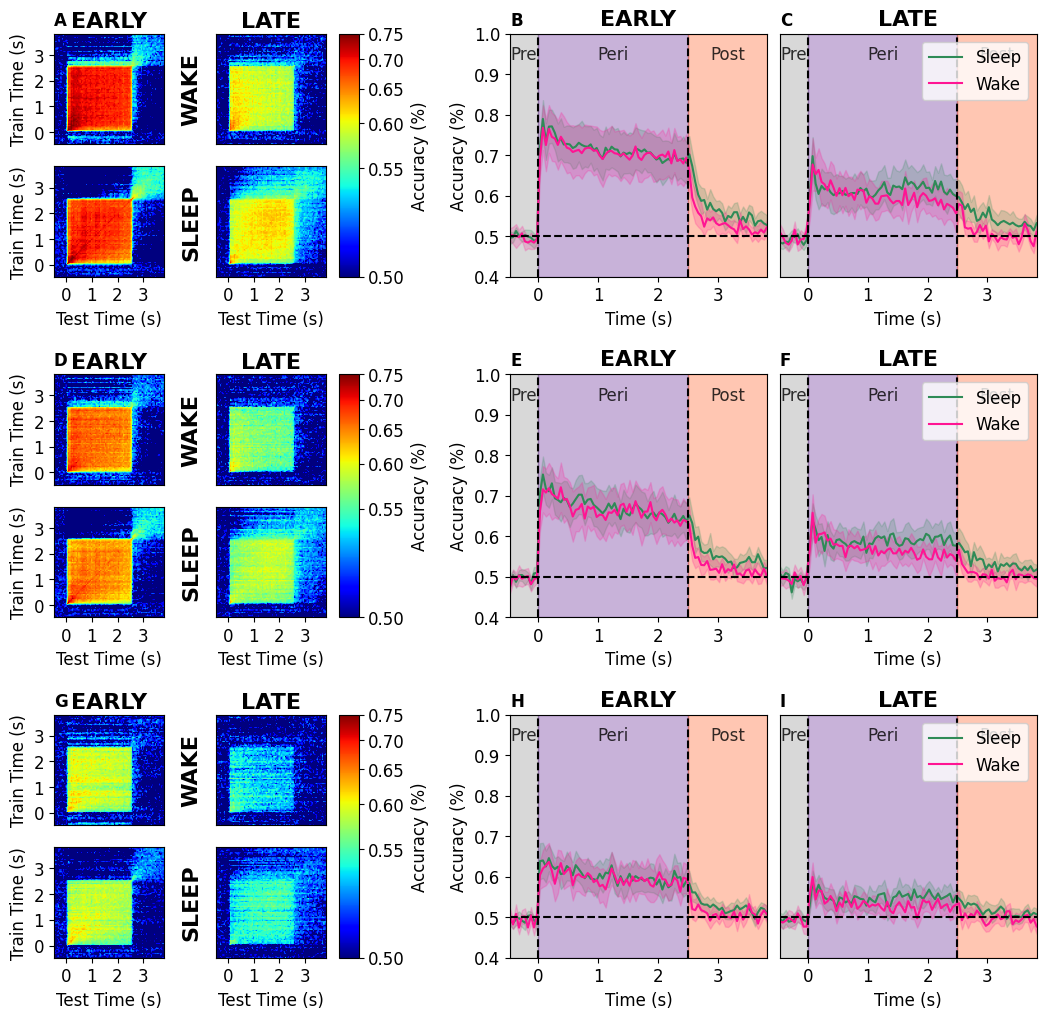

In [44]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
    
fig = plt.figure(figsize=(13, 12))

mpl.rcParams.update({
    'font.size': 12,              # base font size for everything
    'axes.labelsize': 12,         # x/y axis labels
    'axes.titlesize': 12,         # subplot titles (e.g., A–I)
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 12,
})
outer_gs = gridspec.GridSpec(3, 1, hspace=0.4, wspace=0.1)

# A-C. Next stim
gs_row = gridspec.GridSpecFromSubplotSpec(1, 4, width_ratios=[0.9, 0.1, 0.65, 0.65], subplot_spec=outer_gs[0, :], wspace=0.3)
subplot_heatmap = fig.add_subplot(gs_row[0, 0])
subplot_heatmap.axis(False)
gs_subplot_heatmap = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=subplot_heatmap, wspace=0.01)

axs_heatmap = np.array([[fig.add_subplot(gs_subplot_heatmap[i, j]) for j in range(2)] for i in range(2)])
im = plot_heatmap_accuracy(axs_heatmap, mean_std_time_all['Shuffle_neurons_20'], t_hist)
        
if len(axs_heatmap.shape) > 0:
    # Grab the bounding boxes of the top-right subplots
    bbox00 = axs_heatmap[0][0].get_position()
    bbox01 = axs_heatmap[0][1].get_position()
    bbox10 = axs_heatmap[1][0].get_position()
    bbox11 = axs_heatmap[1][1].get_position()

    # Compute midpoints for labels
    mid_y_top = (bbox00.y0 + bbox00.y1) / 2
    mid_y_bottom = (bbox10.y0 + bbox10.y1) / 2
    mid_x_left = (bbox00.x0 + bbox00.x1) / 2
    mid_x_right = (bbox01.x0 + bbox01.x1) / 2
    mid_x = (mid_x_left + mid_x_right) / 2
    mid_y = (mid_y_top + mid_y_bottom) / 2

    # Add labels relative to the 2x2 grid of plots
    fig.text(mid_x + 0.001, mid_y_top, 'WAKE', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
    fig.text(mid_x + 0.001, mid_y_bottom, 'SLEEP', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
    fig.text(mid_x_left, bbox00.y0 + bbox00.height + 0.01, 'EARLY', ha='center', va='center', fontsize=16, weight='bold')
    fig.text(mid_x_right, bbox01.y0 + bbox01.height + 0.01, 'LATE', ha='center', va='center', fontsize=16, weight='bold')

    # Add shared colorbar for top 2x2 only
    # Get the position of the rightmost column (e.g., axs_heatmap[0][1])
    bbox_right = axs_heatmap[0][1].get_position()
    bbox_left = axs_heatmap[1][0].get_position()

    # Define colorbar axes just to the right of the 2x2 grid
    cbar_ax = fig.add_axes([
        bbox_right.x1 + 0.01,               # x: just right of rightmost subplot
        bbox_left.y0,                       # y: align with bottom of lowest subplot
        0.015,                              # width
        bbox_right.y1 - bbox_left.y0        # height: span both rows
    ])

    fig.colorbar(im, cax=cbar_ax, label='Accuracy (%)')
axs_heatmap[0,0].set_title('A', loc='left', fontweight='bold')

subplot_acc_all = fig.add_subplot(gs_row[0, 2:4])
subplot_acc_all.axis(False)
gs_subplot_acc_all = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=subplot_acc_all, wspace=0.05)

axs_avg_acc_time = np.array([fig.add_subplot(gs_subplot_acc_all[0, j]) for j in range(2)])

plot_avg_accuracy_by_state(axs_avg_acc_time, mean_std_time_all['Shuffle_neurons_20'], t_hist)
    
axs_avg_acc_time[0].set_title('B', loc='left', fontweight='bold')
axs_avg_acc_time[1].set_title('C', loc='left', fontweight='bold')

# D-F. First
gs_row = gridspec.GridSpecFromSubplotSpec(1, 4, width_ratios=[0.9, 0.1, 0.65, 0.65], subplot_spec=outer_gs[1, :], wspace=0.3)
subplot_heatmap = fig.add_subplot(gs_row[0, 0])
subplot_heatmap.axis(False)
gs_subplot_heatmap = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=subplot_heatmap, wspace=0.01)

axs_heatmap = np.array([[fig.add_subplot(gs_subplot_heatmap[i, j]) for j in range(2)] for i in range(2)])
im = plot_heatmap_accuracy(axs_heatmap, mean_std_time_all['Shuffle_neurons_50'], t_hist)
        
if len(axs_heatmap.shape) > 0:
    # Grab the bounding boxes of the top-right subplots
    bbox00 = axs_heatmap[0][0].get_position()
    bbox01 = axs_heatmap[0][1].get_position()
    bbox10 = axs_heatmap[1][0].get_position()
    bbox11 = axs_heatmap[1][1].get_position()

    # Compute midpoints for labels
    mid_y_top = (bbox00.y0 + bbox00.y1) / 2
    mid_y_bottom = (bbox10.y0 + bbox10.y1) / 2
    mid_x_left = (bbox00.x0 + bbox00.x1) / 2
    mid_x_right = (bbox01.x0 + bbox01.x1) / 2
    mid_x = (mid_x_left + mid_x_right) / 2
    mid_y = (mid_y_top + mid_y_bottom) / 2

    # Add labels relative to the 2x2 grid of plots
    fig.text(mid_x + 0.001, mid_y_top, 'WAKE', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
    fig.text(mid_x + 0.001, mid_y_bottom, 'SLEEP', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
    fig.text(mid_x_left, bbox00.y0 + bbox00.height + 0.01, 'EARLY', ha='center', va='center', fontsize=16, weight='bold')
    fig.text(mid_x_right, bbox01.y0 + bbox01.height + 0.01, 'LATE', ha='center', va='center', fontsize=16, weight='bold')

    # Add shared colorbar for top 2x2 only
    # Get the position of the rightmost column (e.g., axs_heatmap[0][1])
    bbox_right = axs_heatmap[0][1].get_position()
    bbox_left = axs_heatmap[1][0].get_position()

    # Define colorbar axes just to the right of the 2x2 grid
    cbar_ax = fig.add_axes([
        bbox_right.x1 + 0.01,               # x: just right of rightmost subplot
        bbox_left.y0,                       # y: align with bottom of lowest subplot
        0.015,                              # width
        bbox_right.y1 - bbox_left.y0        # height: span both rows
    ])

    fig.colorbar(im, cax=cbar_ax, label='Accuracy (%)')
axs_heatmap[0,0].set_title('D', loc='left', fontweight='bold')

subplot_acc_all = fig.add_subplot(gs_row[0, 2:4])
subplot_acc_all.axis(False)
gs_subplot_acc_all = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=subplot_acc_all, wspace=0.05)

axs_avg_acc_time = np.array([fig.add_subplot(gs_subplot_acc_all[0, j]) for j in range(2)])

plot_avg_accuracy_by_state(axs_avg_acc_time, mean_std_time_all['Shuffle_neurons_50'], t_hist)
    
axs_avg_acc_time[0].set_title('E', loc='left', fontweight='bold')
axs_avg_acc_time[1].set_title('F', loc='left', fontweight='bold')

# G-I. Last
gs_row = gridspec.GridSpecFromSubplotSpec(1, 4, width_ratios=[0.9, 0.1, 0.65, 0.65], subplot_spec=outer_gs[2, :], wspace=0.3)
subplot_heatmap = fig.add_subplot(gs_row[0, 0])
subplot_heatmap.axis(False)
gs_subplot_heatmap = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=subplot_heatmap, wspace=0.01)

axs_heatmap = np.array([[fig.add_subplot(gs_subplot_heatmap[i, j]) for j in range(2)] for i in range(2)])
im = plot_heatmap_accuracy(axs_heatmap, mean_std_time_all['Shuffle_neurons_80'], t_hist)
        
if len(axs_heatmap.shape) > 0:
    # Grab the bounding boxes of the top-right subplots
    bbox00 = axs_heatmap[0][0].get_position()
    bbox01 = axs_heatmap[0][1].get_position()
    bbox10 = axs_heatmap[1][0].get_position()
    bbox11 = axs_heatmap[1][1].get_position()

    # Compute midpoints for labels
    mid_y_top = (bbox00.y0 + bbox00.y1) / 2
    mid_y_bottom = (bbox10.y0 + bbox10.y1) / 2
    mid_x_left = (bbox00.x0 + bbox00.x1) / 2
    mid_x_right = (bbox01.x0 + bbox01.x1) / 2
    mid_x = (mid_x_left + mid_x_right) / 2
    mid_y = (mid_y_top + mid_y_bottom) / 2

    # Add labels relative to the 2x2 grid of plots
    fig.text(mid_x + 0.001, mid_y_top, 'WAKE', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
    fig.text(mid_x + 0.001, mid_y_bottom, 'SLEEP', ha='center', va='center', fontsize=16, weight='bold', rotation=90)
    fig.text(mid_x_left, bbox00.y0 + bbox00.height + 0.01, 'EARLY', ha='center', va='center', fontsize=16, weight='bold')
    fig.text(mid_x_right, bbox01.y0 + bbox01.height + 0.01, 'LATE', ha='center', va='center', fontsize=16, weight='bold')

    # Add shared colorbar for top 2x2 only
    # Get the position of the rightmost column (e.g., axs_heatmap[0][1])
    bbox_right = axs_heatmap[0][1].get_position()
    bbox_left = axs_heatmap[1][0].get_position()

    # Define colorbar axes just to the right of the 2x2 grid
    cbar_ax = fig.add_axes([
        bbox_right.x1 + 0.01,               # x: just right of rightmost subplot
        bbox_left.y0,                       # y: align with bottom of lowest subplot
        0.015,                              # width
        bbox_right.y1 - bbox_left.y0        # height: span both rows
    ])

    fig.colorbar(im, cax=cbar_ax, label='Accuracy (%)')
axs_heatmap[0,0].set_title('G', loc='left', fontweight='bold')

subplot_acc_all = fig.add_subplot(gs_row[0, 2:4])
subplot_acc_all.axis(False)
gs_subplot_acc_all = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=subplot_acc_all, wspace=0.05)

axs_avg_acc_time = np.array([fig.add_subplot(gs_subplot_acc_all[0, j]) for j in range(2)])

plot_avg_accuracy_by_state(axs_avg_acc_time, mean_std_time_all['Shuffle_neurons_80'], t_hist)

axs_avg_acc_time[0].set_title('H', loc='left', fontweight='bold')
axs_avg_acc_time[1].set_title('I', loc='left', fontweight='bold')

fig.savefig(DATA_PATH + r"\Figure_S2.pdf", format='pdf', dpi=300, transparent=True)
fig.savefig(DATA_PATH + r"\Figure_S2.jpg", dpi=300)